In [48]:
#The data from this project was scraped from the google play app store.
# There is seperate file for the data scraping portion of this project. 
import pandas as pd

df = pd.read_csv(
r"C:\Users\luisr\OneDrive\Desktop\duolingo_reviews_checkpoint.csv"
)
df.head()
#The data frame shows information regarding duolingo reviews. 
#The most important column for this project is the score column (score values range from 1 to 5).

C:\Users\luisr\AppData\Local\Temp\ipykernel_7160\3583480064.py:5: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,a8036071-583d-45de-8be4-741b3a12a50c,Takunda Hlatywayo,https://play-lh.googleusercontent.com/a-/ALV-U...,You are the best,5,0,5.121.14,2026-04-26 19:07:01,NaN,NaN,5.121.14
1,6b35c29b-3100-4d63-9a96-7d16008d504c,Dr Jones,https://play-lh.googleusercontent.com/a-/ALV-U...,I'm stuck at a particular point in this app an...,1,0,6.76.3,2026-04-26 19:06:11,NaN,NaN,6.76.3
2,a1669ffb-cd77-4da7-97cd-231ebc9ffe53,Ayisi Ampofo Albert,https://play-lh.googleusercontent.com/a/ACg8oc...,This is the best learning app I have ever used...,5,0,6.33.4,2026-04-26 19:05:01,NaN,NaN,6.33.4
3,1153c5ae-e5cf-4524-97c8-94dbbd1ca5eb,Lisa Dyosi,https://play-lh.googleusercontent.com/a-/ALV-U...,Cool app,5,0,6.75.7,2026-04-26 18:53:24,NaN,NaN,6.75.7
4,a80b95e6-8fea-4a5b-beb0-efde7a6fcffa,Rossana Menezes,https://play-lh.googleusercontent.com/a-/ALV-U...,STOP SHOWING PEOPLE I DONT FOLLOW ON MY FEED!!...,1,2,6.76.3,2026-04-26 18:47:46,NaN,NaN,6.76.3


In [49]:
#Some of the columns in the data frame need to be converted to date-time format. 
#This allows for easier plotting.

df["at"] = pd.to_datetime(df["at"])
df["year"] = df["at"].dt.year
df["month"] = df["at"].dt.month
df[["at", "year", "month"]].head()

,at,year,month
0,2026-04-26 19:07:01,2026,4
1,2026-04-26 19:06:11,2026,4
2,2026-04-26 19:05:01,2026,4
3,2026-04-26 18:53:24,2026,4
4,2026-04-26 18:47:46,2026,4


In [52]:
# Counts the number of rows (reviews) in each year–month group
reviews_per_month = df.groupby(["year", "month"]).size()
reviews_per_month

year  month
2021  4         1116
      5        14285
      6        13861
      7        15100
      8        14010
               ...  
2025  12       42058
2026  1        39932
      2        37476
      3        34682
      4        24714
Length: 61, dtype: int64

In [53]:
#from the cell above, data may seem truncated
#as if there isn't data between 2021 and 2025. This cell just checks that there is.
reviews_per_month = reviews_per_month.sort_index()

missing_check = reviews_per_month.unstack(fill_value=0)

missing_check
#we can also see that our data spans roughly 5 years, which is enough time to spot trends

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2021,0,0,0,1116,14285,13861,15100,14010,14622,14115,4826,5100
2022,5474,4641,23265,19074,15820,32591,19753,20593,17486,17069,26430,18961
2023,19966,17671,17839,17297,16775,17712,47593,47881,36972,38669,38470,37964
2024,42425,33883,38922,42804,37675,34492,35717,44340,45037,34915,35748,40108
2025,41790,42368,43434,35958,55263,42781,39413,42695,48722,48467,48966,42058
2026,39932,37476,34682,24714,0,0,0,0,0,0,0,0


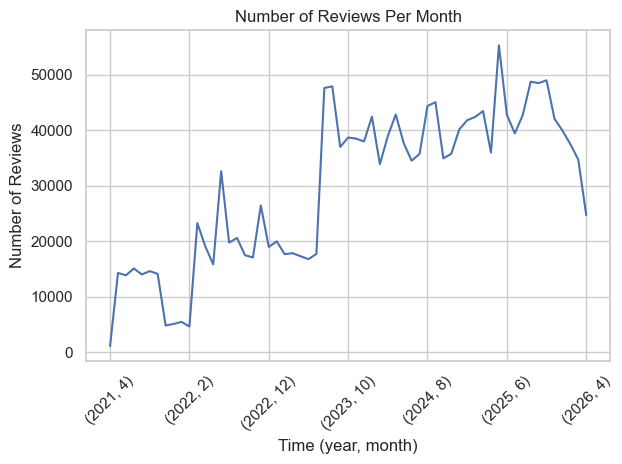

In [55]:
#The graph below shows how the number of reviews has changed over time,
#but it still doesn't descriminate between score ratings from 1 to 5.
import matplotlib.pyplot as plt

reviews_per_month.plot()

plt.title("Number of Reviews Per Month")
plt.xlabel("Time (year, month)")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [57]:
#Here, we show the average score for each month** in the data 
#(**each INDIVIDUAL month, not the average for every December or January, for example)
avg_score_per_month = (
    df.groupby(["year", "month"])["score"]
    .mean()    
)
avg_score_per_month

year  month
2021  4        4.452509
      5        4.466013
      6        4.468076
      7        4.472119
      8        4.438972
                 ...   
2025  12       4.382543
2026  1        4.429079
      2        4.432650
      3        4.419843
      4        4.329975
Name: score, Length: 61, dtype: float64

In [65]:
avg_score_per_month = (
    df.groupby(["year", "month"])["score"]
    .mean()
    .reset_index()
    .rename(columns={"score": "average score"})
)

In [70]:
#This code is creating a proper datetime column from the separate year and month columns 
# so the data can be treated as a time series (for plotting, sorting, resampling, etc.).
avg_score_per_month["date"] = pd.to_datetime(
    avg_score_per_month["year"].astype(str) + "-" +
    avg_score_per_month["month"].astype(str)
)

avg_score_per_month.head()

,year,month,average score,date
0,2021,4,4.452509,2021-04-01
1,2021,5,4.466013,2021-05-01
2,2021,6,4.468076,2021-06-01
3,2021,7,4.472119,2021-07-01
4,2021,8,4.438972,2021-08-01


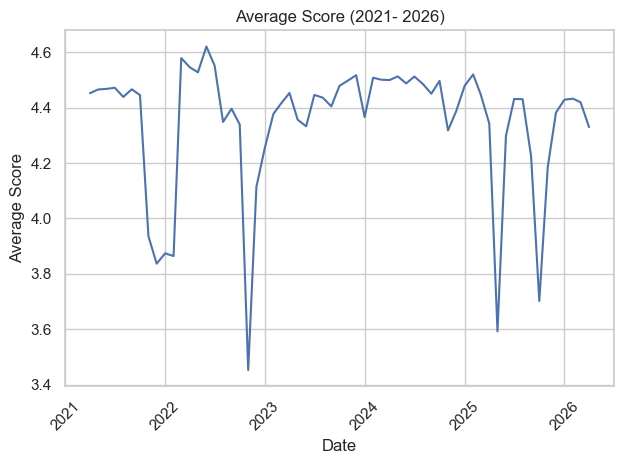

In [82]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(
    avg_score_per_month["date"],
    avg_score_per_month["average score"]
)

plt.title("Average Score (2021- 2026)")
plt.xlabel("Date")
plt.ylabel("Average Score")

plt.xticks(rotation=45)   # tilts the x-axis labels
plt.tight_layout()        # prevents labels from getting cut off

plt.show()

In [73]:
#next step: Are users mostly giving high ratings, low ratings, or a mix?
score_counts = df["score"].value_counts().sort_index()

score_counts

score
1     150619
2      49425
3      86757
4     230150
5    1290835
Name: count, dtype: int64

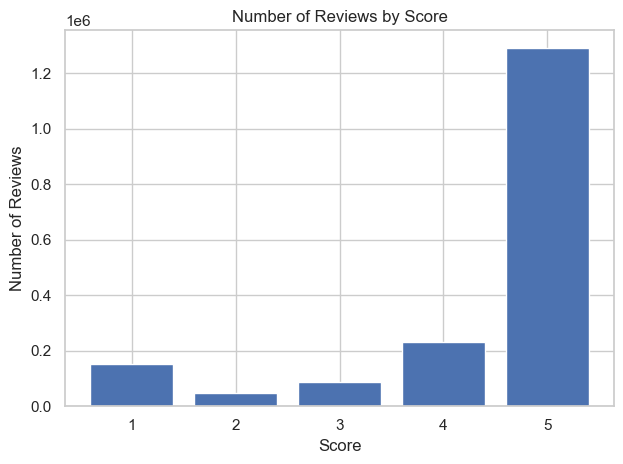

In [83]:
#this shows the total distribution of scores across the whole time range
import matplotlib.pyplot as plt

plt.figure()

plt.bar(
    score_counts.index,
    score_counts.values
)

plt.title("Number of Reviews by Score")
plt.xlabel("Score")
plt.ylabel("Number of Reviews")

plt.xticks([1, 2, 3, 4, 5])

plt.tight_layout()

plt.show()

In [84]:
# What percentage of reviews are 1-star vs 5-star?
score_percent = df["score"].value_counts(normalize=True).sort_index() * 100

score_percent

score
1     8.331683
2     2.734007
3     4.799075
4    12.731042
5    71.404193
Name: proportion, dtype: float64

In [85]:
#Are certain scores concentrated in specific months?
monthly_score_counts = (
    df.groupby(["year", "month", "score"])
    .size()
    .reset_index(name="count")
)

monthly_score_counts

,year,month,score,count
0,2021,4,1,71
1,2021,4,2,32
2,2021,4,3,45
3,2021,4,4,141
4,2021,4,5,827
...,...,...,...,...
300,2026,4,1,2115
301,2026,4,2,799
302,2026,4,3,1302
303,2026,4,4,3098


In [86]:
pivot_scores = monthly_score_counts.pivot(
    index=["year", "month"],
    columns="score",
    values="count"
).fillna(0)

pivot_scores

score          1     2     3     4      5
year month                               
2021 4        71    32    45   141    827
     5       900   316   576  1928  10565
     6       819   331   602  1900  10209
     7       924   360   658  1879  11279
     8       922   349   619  1887  10233
...          ...   ...   ...   ...    ...
2025 12     3251  1123  2027  5542  30115
2026 1      2709   961  1961  5157  29144
     2      2591   879  1731  4799  27476
     3      2421   882  1693  4405  25281
     4      2115   799  1302  3098  17400

[61 rows x 5 columns]

In [88]:
monthly_score_counts = (
    df.groupby(["year", "month", "score"])
    .size()
    .reset_index(name="count")
)

monthly_score_counts["date"] = pd.to_datetime(
    monthly_score_counts[["year", "month"]].assign(day=1)
)

pivot_scores = monthly_score_counts.pivot(
    index="date",
    columns="score",
    values="count"
).fillna(0).sort_index()

pivot_scores

score,1,2,3,4,5
date,,,,,
2021-04-01,71,32,45,141,827
2021-05-01,900,316,576,1928,10565
2021-06-01,819,331,602,1900,10209
2021-07-01,924,360,658,1879,11279
2021-08-01,922,349,619,1887,10233
...,...,...,...,...,...
2025-12-01,3251,1123,2027,5542,30115
2026-01-01,2709,961,1961,5157,29144
2026-02-01,2591,879,1731,4799,27476


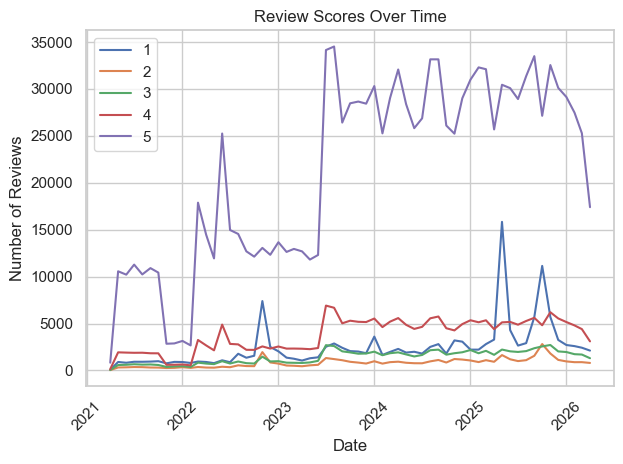

In [89]:
#we can see from the graph below that most of the scores seem to follow one another; 
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

for score in pivot_scores.columns:
    ax.plot(pivot_scores.index, pivot_scores[score], label=f"{score}")

ax.set_title("Review Scores Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Reviews")

plt.xticks(rotation=45)
ax.legend()

plt.tight_layout()
plt.show()